<a href="https://colab.research.google.com/github/TyrGunllod/TELECOMX_ETL/blob/main/TelecomX_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [257]:
!pip install unidecode

Importação das Bibliotecas

In [256]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns
import unidecode
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px


#📌 Extracão

Carregamento dos dados

In [258]:
dados_base = pd.read_json("https://raw.githubusercontent.com/TyrGunllod/TELECOMX_ETL/refs/heads/main/dados/TelecomX_Data.json")
dados_base.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformação

Nova base sem as colunas aninhadas para concatenação

In [135]:
df_cust_churn = dados_base.drop(columns=['customer', 'phone', 'internet', 'account'])
df_cust_churn

,customerID,Churn
0,0002-ORFBO,No
1,0003-MKNFE,No
2,0004-TLHLJ,Yes
3,0011-IGKFF,Yes
4,0013-EXCHZ,Yes
...,...,...
7262,9987-LUTYD,No
7263,9992-RRAMN,Yes
7264,9992-UJOEL,No
7265,9993-LHIEB,No


Normaliza várias colunas aninhadas

In [136]:
df_customer = pd.json_normalize(dados_base["customer"])
df_phone    = pd.json_normalize(dados_base["phone"])
df_internet = pd.json_normalize(dados_base["internet"])
df_account  = pd.json_normalize(dados_base["account"])


Junta tudo no mesmo DataFrame

In [137]:
df_base_norm = pd.concat([df_cust_churn, df_customer, df_phone, df_internet, df_account], axis=1)
df_base_norm.head(3)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


Verifica a quantidade de linhas e colunas

In [138]:
df_base_norm.shape

(7267, 21)

Verifica valores nulos e o tipo

In [139]:
df_base_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


Verifica as possibilidades de resposta das colunas

In [140]:
for col in df_base_norm.columns:
    unicos = df_base_norm[col].unique()
    print(f"Coluna: {col}")
    print(f"Quantidade de valores únicos: {len(unicos)}")
    print(f"Valores únicos: {unicos}")
    print("-" * 50)

Coluna: customerID
Quantidade de valores únicos: 7267
Valores únicos: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
--------------------------------------------------
Coluna: Churn
Quantidade de valores únicos: 3
Valores únicos: ['No' 'Yes' '']
--------------------------------------------------
Coluna: gender
Quantidade de valores únicos: 2
Valores únicos: ['Female' 'Male']
--------------------------------------------------
Coluna: SeniorCitizen
Quantidade de valores únicos: 2
Valores únicos: [0 1]
--------------------------------------------------
Coluna: Partner
Quantidade de valores únicos: 2
Valores únicos: ['Yes' 'No']
--------------------------------------------------
Coluna: Dependents
Quantidade de valores únicos: 2
Valores únicos: ['Yes' 'No']
--------------------------------------------------
Coluna: tenure
Quantidade de valores únicos: 73
Valores únicos: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 

Removendo registros nulos do churn

In [141]:
remover = df_base_norm.query('Churn == ""').index
df_base_norm.drop(remover, axis=0, inplace=True)
df_base_norm['Churn'].unique()

array(['No', 'Yes'], dtype=object)

Transforma todos os dados em string para normalização

In [142]:
df_base_norm = df_base_norm.astype(str)
df_base_norm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7043 non-null   object
 1   Churn             7043 non-null   object
 2   gender            7043 non-null   object
 3   SeniorCitizen     7043 non-null   object
 4   Partner           7043 non-null   object
 5   Dependents        7043 non-null   object
 6   tenure            7043 non-null   object
 7   PhoneService      7043 non-null   object
 8   MultipleLines     7043 non-null   object
 9   InternetService   7043 non-null   object
 10  OnlineSecurity    7043 non-null   object
 11  OnlineBackup      7043 non-null   object
 12  DeviceProtection  7043 non-null   object
 13  TechSupport       7043 non-null   object
 14  StreamingTV       7043 non-null   object
 15  StreamingMovies   7043 non-null   object
 16  Contract          7043 non-null   object
 17  PaperlessBilling  7

Normaliza nomes das colunas

In [143]:
df_base_norm.columns = (
    df_base_norm.columns
    .str.strip()                # remove espaços no começo/fim
    .str.lower()                # tudo minúsculo
    .str.replace(" ", "_")      # troca espaço por "_"
    .str.replace(r"[^a-z0-9_]", "", regex=True)  # remove caracteres especiais
)

df_base_norm.columns = [unidecode.unidecode(col) for col in df_base_norm.columns]
df_base_norm.head()

,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,...,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,chargesmonthly,chargestotal
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [144]:
df_base_norm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerid        7043 non-null   object
 1   churn             7043 non-null   object
 2   gender            7043 non-null   object
 3   seniorcitizen     7043 non-null   object
 4   partner           7043 non-null   object
 5   dependents        7043 non-null   object
 6   tenure            7043 non-null   object
 7   phoneservice      7043 non-null   object
 8   multiplelines     7043 non-null   object
 9   internetservice   7043 non-null   object
 10  onlinesecurity    7043 non-null   object
 11  onlinebackup      7043 non-null   object
 12  deviceprotection  7043 non-null   object
 13  techsupport       7043 non-null   object
 14  streamingtv       7043 non-null   object
 15  streamingmovies   7043 non-null   object
 16  contract          7043 non-null   object
 17  paperlessbilling  7

Normaliza dados em todas as colunas object

In [145]:
for col in df_base_norm.select_dtypes(include="object").columns:
    df_base_norm[col] = df_base_norm[col].str.strip().str.lower().str.replace(" ", "_")

df_base_norm.head()

,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,...,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,chargesmonthly,chargestotal
0,0002-orfbo,no,female,0,yes,yes,9,yes,no,dsl,...,yes,no,yes,yes,no,one_year,yes,mailed_check,65.6,593.3
1,0003-mknfe,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,no,yes,month-to-month,no,mailed_check,59.9,542.4
2,0004-tlhlj,yes,male,0,no,no,4,yes,no,fiber_optic,...,no,yes,no,no,no,month-to-month,yes,electronic_check,73.9,280.85
3,0011-igkff,yes,male,1,yes,no,13,yes,no,fiber_optic,...,yes,yes,no,yes,yes,month-to-month,yes,electronic_check,98.0,1237.85
4,0013-exchz,yes,female,1,yes,no,3,yes,no,fiber_optic,...,no,no,yes,yes,no,month-to-month,yes,mailed_check,83.9,267.4


In [146]:
df_base_norm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerid        7043 non-null   object
 1   churn             7043 non-null   object
 2   gender            7043 non-null   object
 3   seniorcitizen     7043 non-null   object
 4   partner           7043 non-null   object
 5   dependents        7043 non-null   object
 6   tenure            7043 non-null   object
 7   phoneservice      7043 non-null   object
 8   multiplelines     7043 non-null   object
 9   internetservice   7043 non-null   object
 10  onlinesecurity    7043 non-null   object
 11  onlinebackup      7043 non-null   object
 12  deviceprotection  7043 non-null   object
 13  techsupport       7043 non-null   object
 14  streamingtv       7043 non-null   object
 15  streamingmovies   7043 non-null   object
 16  contract          7043 non-null   object
 17  paperlessbilling  7

Verificação dos dados das colunas

In [147]:
for col in df_base_norm.columns:
    unicos = df_base_norm[col].unique()
    print(f"Coluna: {col}")
    print(f"Quantidade de valores únicos: {len(unicos)}")
    print(f"Valores únicos: {unicos}")
    print("-" * 50)

Coluna: customerid
Quantidade de valores únicos: 7043
Valores únicos: ['0002-orfbo' '0003-mknfe' '0004-tlhlj' ... '9992-ujoel' '9993-lhieb'
 '9995-hotoh']
--------------------------------------------------
Coluna: churn
Quantidade de valores únicos: 2
Valores únicos: ['no' 'yes']
--------------------------------------------------
Coluna: gender
Quantidade de valores únicos: 2
Valores únicos: ['female' 'male']
--------------------------------------------------
Coluna: seniorcitizen
Quantidade de valores únicos: 2
Valores únicos: ['0' '1']
--------------------------------------------------
Coluna: partner
Quantidade de valores únicos: 2
Valores únicos: ['yes' 'no']
--------------------------------------------------
Coluna: dependents
Quantidade de valores únicos: 2
Valores únicos: ['yes' 'no']
--------------------------------------------------
Coluna: tenure
Quantidade de valores únicos: 73
Valores únicos: ['9' '4' '13' '3' '71' '63' '7' '65' '54' '72' '5' '56' '34' '1' '45' '50'
 '23' '

Reordena as colunas

In [148]:
# Lista na ordem desejada
nova_ordem = ["customerid", "gender", "contract", "paymentmethod",
              "internetservice", "chargesmonthly", "chargestotal",
              "tenure", "paperlessbilling",
              "dependents", "seniorcitizen", "partner",
              "phoneservice", "multiplelines",
              "onlinesecurity", "onlinebackup", "deviceprotection",
              "techsupport", "streamingtv", "streamingmovies", "churn"]

# Reorganiza o DataFrame
df_base_norm = df_base_norm[nova_ordem]

df_base_norm.head()

,customerid,gender,contract,paymentmethod,internetservice,chargesmonthly,chargestotal,tenure,paperlessbilling,dependents,...,partner,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,churn
0,0002-orfbo,female,one_year,mailed_check,dsl,65.6,593.3,9,yes,yes,...,yes,yes,no,no,yes,no,yes,yes,no,no
1,0003-mknfe,male,month-to-month,mailed_check,dsl,59.9,542.4,9,no,no,...,no,yes,yes,no,no,no,no,no,yes,no
2,0004-tlhlj,male,month-to-month,electronic_check,fiber_optic,73.9,280.85,4,yes,no,...,no,yes,no,no,no,yes,no,no,no,yes
3,0011-igkff,male,month-to-month,electronic_check,fiber_optic,98.0,1237.85,13,yes,no,...,yes,yes,no,no,yes,yes,no,yes,yes,yes
4,0013-exchz,female,month-to-month,mailed_check,fiber_optic,83.9,267.4,3,yes,no,...,yes,yes,no,no,no,no,yes,yes,no,yes


Criar nova base, removendo os campos desnecessários e ordenando por categóricas e numéricas

In [149]:
colunas_uteis = ['gender',  'contract', 'paymentmethod',
                 'internetservice', 'chargesmonthly', 'chargestotal', 'tenure',
                 'dependents', 'seniorcitizen', 'partner', 'phoneservice',
                 'churn']

df_base_util = df_base_norm[colunas_uteis].copy()
df_base_util.head()

,gender,contract,paymentmethod,internetservice,chargesmonthly,chargestotal,tenure,dependents,seniorcitizen,partner,phoneservice,churn
0,female,one_year,mailed_check,dsl,65.6,593.3,9,yes,0,yes,yes,no
1,male,month-to-month,mailed_check,dsl,59.9,542.4,9,no,0,no,yes,no
2,male,month-to-month,electronic_check,fiber_optic,73.9,280.85,4,no,0,no,yes,yes
3,male,month-to-month,electronic_check,fiber_optic,98.0,1237.85,13,no,1,yes,yes,yes
4,female,month-to-month,mailed_check,fiber_optic,83.9,267.4,3,no,1,yes,yes,yes


Converte "Yes" ou "No" em 1 e 0

In [150]:
# Define as colunas que deseja converter
colunas_binarias = ["churn", "partner", "dependents", "phoneservice"]

# Substitui apenas nessas colunas
df_base_util[colunas_binarias] = (df_base_util[colunas_binarias]
                                  .replace({"yes": 1, "no": 0})
                                  .infer_objects(copy=False))

df_base_util.head()

/tmp/ipython-input-3316956597.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"yes": 1, "no": 0})


,gender,contract,paymentmethod,internetservice,chargesmonthly,chargestotal,tenure,dependents,seniorcitizen,partner,phoneservice,churn
0,female,one_year,mailed_check,dsl,65.6,593.3,9,1,0,1,1,0
1,male,month-to-month,mailed_check,dsl,59.9,542.4,9,0,0,0,1,0
2,male,month-to-month,electronic_check,fiber_optic,73.9,280.85,4,0,0,0,1,1
3,male,month-to-month,electronic_check,fiber_optic,98.0,1237.85,13,0,1,1,1,1
4,female,month-to-month,mailed_check,fiber_optic,83.9,267.4,3,0,1,1,1,1


In [151]:
df_base_util.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gender           7043 non-null   object
 1   contract         7043 non-null   object
 2   paymentmethod    7043 non-null   object
 3   internetservice  7043 non-null   object
 4   chargesmonthly   7043 non-null   object
 5   chargestotal     7043 non-null   object
 6   tenure           7043 non-null   object
 7   dependents       7043 non-null   int64 
 8   seniorcitizen    7043 non-null   object
 9   partner          7043 non-null   int64 
 10  phoneservice     7043 non-null   int64 
 11  churn            7043 non-null   int64 
dtypes: int64(4), object(8)
memory usage: 715.3+ KB


Convertendo para as unidades corretas

In [152]:
# Colunas str para float
cols_convert = ['tenure', 'chargesmonthly', 'chargestotal']

df_base_util[cols_convert] = df_base_util[cols_convert].apply(
    pd.to_numeric, errors="coerce"
)

# Coluna para inteiro
df_base_util['seniorcitizen'] = df_base_util['seniorcitizen'].astype(int)

df_base_util.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           7043 non-null   object 
 1   contract         7043 non-null   object 
 2   paymentmethod    7043 non-null   object 
 3   internetservice  7043 non-null   object 
 4   chargesmonthly   7043 non-null   float64
 5   chargestotal     7032 non-null   float64
 6   tenure           7043 non-null   int64  
 7   dependents       7043 non-null   int64  
 8   seniorcitizen    7043 non-null   int64  
 9   partner          7043 non-null   int64  
 10  phoneservice     7043 non-null   int64  
 11  churn            7043 non-null   int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 715.3+ KB


Criando coluna contas_diarias

In [153]:
df_base_util["contas_diarias"] = df_base_util["chargesmonthly"] / 30
df_base_util.head()

,gender,contract,paymentmethod,internetservice,chargesmonthly,chargestotal,tenure,dependents,seniorcitizen,partner,phoneservice,churn,contas_diarias
0,female,one_year,mailed_check,dsl,65.6,593.30,9,1,0,1,1,0,2.186667
1,male,month-to-month,mailed_check,dsl,59.9,542.40,9,0,0,0,1,0,1.996667
2,male,month-to-month,electronic_check,fiber_optic,73.9,280.85,4,0,0,0,1,1,2.463333
3,male,month-to-month,electronic_check,fiber_optic,98.0,1237.85,13,0,1,1,1,1,3.266667
4,female,month-to-month,mailed_check,fiber_optic,83.9,267.40,3,0,1,1,1,1,2.796667


#📊 Carga e análise

Describe por tipo

In [154]:
df_base_util.describe(include='object')

,gender,contract,paymentmethod,internetservice
count,7043,7043,7043,7043
unique,2,3,4,3
top,male,month-to-month,electronic_check,fiber_optic
freq,3555,3875,2365,3096


In [157]:
df_base_util.describe(include='int64')

,tenure,dependents,seniorcitizen,partner,phoneservice,churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,0.299588,0.162147,0.483033,0.903166,0.265370
std,24.559481,0.458110,0.368612,0.499748,0.295752,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,29.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,55.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [156]:
df_base_util.describe(include='float64')

,chargesmonthly,chargestotal,contas_diarias
count,7043.000000,7032.000000,7043.000000
mean,64.761692,2283.300441,2.158723
std,30.090047,2266.771362,1.003002
min,18.250000,18.800000,0.608333
25%,35.500000,401.450000,1.183333
50%,70.350000,1397.475000,2.345000
75%,89.850000,3794.737500,2.995000
max,118.750000,8684.800000,3.958333


Plotagem por churn

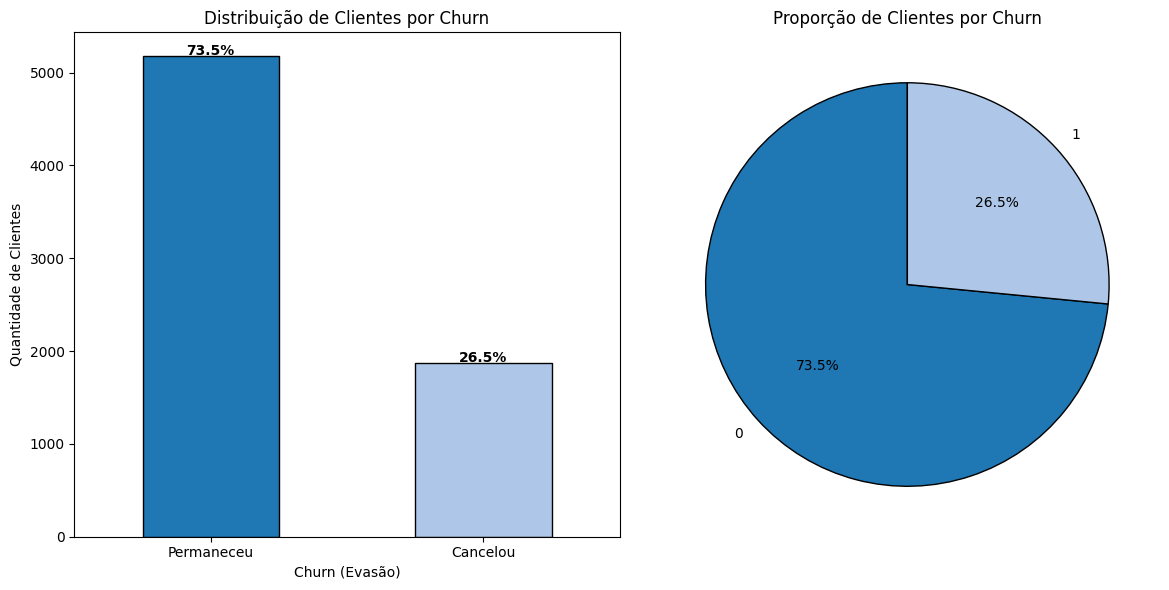

In [188]:
# Conta as ocorrências de cada categoria de churn
contagem_churn = df_base_util["churn"].value_counts()

# Calcula a proporção (percentual) de cada categoria
proporcao_churn = df_base_util["churn"].value_counts(normalize=True) * 100

# Cria figura com 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# -------------------------
# Gráfico de barras com colormap
# -------------------------
ax = axes[0]
cores = plt.cm.tab20.colors  # colormap para as barras
contagem_churn.plot(kind="bar", color=cores[:len(contagem_churn)], edgecolor="black", ax=ax)
ax.set_title("Distribuição de Clientes por Churn")
ax.set_xlabel("Churn (Evasão)")
ax.set_ylabel("Quantidade de Clientes")
ax.set_xticklabels(["Permaneceu", "Cancelou"], rotation=0)

# Adiciona rótulos de porcentagem em cima das barras
for i, valor in enumerate(contagem_churn):
    percent = proporcao_churn[i]
    ax.text(i, valor + 10, f"{percent:.1f}%", ha="center", fontsize=10, fontweight="bold")

# -------------------------
# Gráfico de pizza com colormap
# -------------------------
ax = axes[1]
cores_pizza = plt.cm.tab20.colors[:len(proporcao_churn)]  # mesmo colormap para pizza
proporcao_churn.plot(kind="pie", autopct="%.1f%%", colors=cores_pizza,
                     startangle=90, wedgeprops={"edgecolor":"black"}, ax=ax)
ax.set_title("Proporção de Clientes por Churn")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

Plotagem por variáveis categóricas

In [261]:
# -----------------------------
# Variáveis categóricas
# -----------------------------
categoricas = ['gender', 'contract', 'paymentmethod', 'internetservice']
n_colunas = 1
n_linhas = len(categoricas)

# Criando subplot para categóricas
fig_cat = make_subplots(
    rows=n_linhas,
    cols=n_colunas,
    subplot_titles=categoricas,
    vertical_spacing=0.06,
    horizontal_spacing=0.05
)

cores_barras = px.colors.sequential.Plasma

for i, var in enumerate(categoricas):
    df_cat = df_base_util.groupby(var)['churn'].mean().reset_index()
    df_cat['churn_%'] = df_cat['churn'] * 100
    df_cat = df_cat.sort_values('churn_%', ascending=True)

    for j, val in enumerate(df_cat[var]):
        fig_cat.add_trace(go.Bar(
            x=[df_cat.loc[j,'churn_%']],
            y=[val],
            orientation='h',
            name=str(val),
            marker_color=cores_barras[j % len(cores_barras)],
            text=f"{df_cat.loc[j,'churn_%']:.1f}%",
            textposition='outside',
            showlegend=False
        ), row=i+1, col=1)

fig_cat.update_layout(
    margin=dict(l=30, r=30, t=100, b=50),
    height=300*n_linhas,
    width=1000,
    title_text="Proporção de Churn - Variáveis Categóricas",
    showlegend=False
)

fig_cat.show()


Plotagem por variáveis numéricas

In [266]:
# -----------------------------
# Variáveis numéricas
# -----------------------------
numericas = ['tenure', 'dependents', 'seniorcitizen', 'partner',
             'phoneservice', 'chargesmonthly', 'chargestotal', 'contas_diarias']
n_colunas = 1
n_linhas = len(numericas)

# Criando subplot para numéricas
fig_num = make_subplots(
    rows=n_linhas,
    cols=n_colunas,
    subplot_titles=numericas,
    vertical_spacing=0.04,
    horizontal_spacing=0.05
)

cores_box = px.colors.qualitative.Plotly

for i, var in enumerate(numericas):
    # Boxplot churn=0
    fig_num.add_trace(go.Box(
        y=df_base_util[df_base_util['churn']==0][var],
        name='Permaneceu (0)',
        marker_color=cores_box[0],
        boxmean='sd'
    ), row=i+1, col=1)

    # Boxplot churn=1
    fig_num.add_trace(go.Box(
        y=df_base_util[df_base_util['churn']==1][var],
        name='Cancelou (1)',
        marker_color=cores_box[1],
        boxmean='sd'
    ), row=i+1, col=1)

fig_num.update_layout(
    margin=dict(l=50, r=50, t=100, b=50),
    height=300*n_linhas,
    width=1000,
    title_text="Distribuição das Variáveis Numéricas por Churn",
    showlegend=False
)

fig_num.show()


Análise dos dados e possíveis causas

In [269]:
# -----------------------------
# Função para analisar churn
# -----------------------------
def analisar_churn(df):
    motivos = []

    # -----------------------------
    # Variáveis categóricas
    # -----------------------------
    categoricas = ['gender', 'contract', 'paymentmethod', 'internetservice', 'partner', 'dependents', 'phoneservice']

    for var in categoricas:
        # Calcula proporção de churn por categoria
        prop = df.groupby(var)['churn'].mean() * 100
        maior_churn = prop.idxmax()
        valor_churn = prop.max()

        if valor_churn > 30:  # arbitrário: considera relevante acima de 30%
            motivos.append(f"Clientes com {var} = {maior_churn} têm alta taxa de evasão ({valor_churn:.1f}%)")

    # -----------------------------
    # Variáveis numéricas
    # -----------------------------
    numericas = ['tenure', 'chargesmonthly', 'chargestotal', 'contas_diarias', 'seniorcitizen']

    for var in numericas:
        media_churn = df[df['churn']==1][var].mean()
        media_nao_churn = df[df['churn']==0][var].mean()

        # Avalia diferença significativa (arbitrária > 20% da média)
        if abs(media_churn - media_nao_churn)/df[var].mean() > 0.2:
            motivos.append(f"Clientes que cancelaram têm média de {var} ({media_churn:.2f}) diferente de quem permaneceu ({media_nao_churn:.2f})")

    # -----------------------------
    # Retorna os possíveis motivos
    # -----------------------------
    if len(motivos) == 0:
        return ["Nenhum fator claro identificado. Talvez seja necessário coletar mais dados."]
    else:
        return motivos

# -----------------------------
# Executar análise
# -----------------------------
motivos_evasao = analisar_churn(df_base_util)

print("Possíveis motivos de evasão identificados:\n")
for motivo in motivos_evasao:
    print("-", motivo)


Possíveis motivos de evasão identificados:

- Clientes com contract = month-to-month têm alta taxa de evasão (42.7%)
- Clientes com paymentmethod = electronic_check têm alta taxa de evasão (45.3%)
- Clientes com internetservice = fiber_optic têm alta taxa de evasão (41.9%)
- Clientes com partner = 0 têm alta taxa de evasão (33.0%)
- Clientes com dependents = 0 têm alta taxa de evasão (31.3%)
- Clientes que cancelaram têm média de tenure (17.98) diferente de quem permaneceu (37.57)
- Clientes que cancelaram têm média de chargesmonthly (74.44) diferente de quem permaneceu (61.27)
- Clientes que cancelaram têm média de chargestotal (1531.80) diferente de quem permaneceu (2555.34)
- Clientes que cancelaram têm média de contas_diarias (2.48) diferente de quem permaneceu (2.04)
- Clientes que cancelaram têm média de seniorcitizen (0.25) diferente de quem permaneceu (0.13)


#📄Relatorio Final

In [277]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from IPython.display import display, HTML

def gerar_relatorio_colab(df):
    display(HTML("<h1 style='color:#1f77b4;'>🧾 Relatório Final – Análise de Evasão de Clientes (Churn)</h1>"))

    # -----------------------------
    # 1️⃣ Introdução
    # -----------------------------
    display(HTML("""
    <h2 style='color:#ff7f0e;'>1️⃣ Introdução</h2>
    <p>O objetivo deste relatório é identificar os fatores que influenciam a evasão de clientes (churn)
    da base de dados analisada. A partir dessa análise, é possível tomar decisões estratégicas para reduzir
    a evasão e melhorar a retenção de clientes.</p>
    <p>A análise considerou variáveis categóricas (perfil do cliente e serviço contratado) e variáveis numéricas
    (tempo de contrato, valores de cobrança e uso diário), relacionando-as ao comportamento de churn.</p>
    """))

    # -----------------------------
    # 2️⃣ Variáveis Categóricas
    # -----------------------------
    categoricas = ['contract', 'paymentmethod', 'internetservice', 'partner', 'dependents']
    display(HTML("<h2 style='color:#ff7f0e;'>2️⃣ Principais Insights – Variáveis Categóricas</h2>"))

    # Gerar tabela resumida
    tabela_cat = []
    for var in categoricas:
        prop = df.groupby(var)['churn'].mean() * 100
        maior_churn = prop.idxmax()
        valor_churn = round(prop.max(),1)
        tabela_cat.append([var, maior_churn, valor_churn])
    df_cat_summary = pd.DataFrame(tabela_cat, columns=['Variável','Categoria','Taxa de Evasão (%)'])
    display(HTML(df_cat_summary.to_html(index=False, escape=False)))

    display(HTML("""
    <p>Interpretação:</p>
    <ul>
        <li>Clientes com contratos de curto prazo (month-to-month) apresentam maior risco de cancelamento.</li>
        <li>Clientes que utilizam electronic_check como método de pagamento têm maior probabilidade de churn.</li>
        <li>Serviços de internet fibra óptica mostram maior evasão, possivelmente devido ao custo ou expectativa de desempenho.</li>
        <li>Clientes sem parceiros ou dependentes tendem a cancelar mais frequentemente.</li>
    </ul>
    """))

    # -----------------------------
    # 3️⃣ Variáveis Numéricas
    # -----------------------------
    numericas = ['tenure', 'chargesmonthly', 'chargestotal', 'contas_diarias', 'seniorcitizen']
    display(HTML("<h2 style='color:#ff7f0e;'>3️⃣ Principais Insights – Variáveis Numéricas</h2>"))

    tabela_num = []
    for var in numericas:
        media_churn = round(df[df['churn']==1][var].mean(),2)
        media_nao_churn = round(df[df['churn']==0][var].mean(),2)
        if var == 'tenure':
            obs = "Clientes que cancelaram permanecem menos tempo."
        elif var == 'chargesmonthly':
            obs = "Clientes que cancelaram têm cobrança mensal mais alta."
        elif var == 'chargestotal':
            obs = "Apesar de menor tempo, gasto total menor."
        elif var == 'contas_diarias':
            obs = "Clientes mais ativos diariamente tendem a cancelar mais."
        elif var == 'seniorcitizen':
            obs = "Clientes idosos apresentam maior churn relativo."
        tabela_num.append([var, media_churn, media_nao_churn, obs])
    df_num_summary = pd.DataFrame(tabela_num, columns=['Variável','Média Churn=1','Média Churn=0','Observação'])
    display(HTML(df_num_summary.to_html(index=False, escape=False)))

    display(HTML("""
    <p>Interpretação:</p>
    <ul>
        <li>Tempo de contrato curto (menor tenure) aumenta a probabilidade de churn.</li>
        <li>Cobrança mensal mais alta pode impactar negativamente a retenção.</li>
        <li>Clientes mais ativos diariamente ou idosos possuem maior risco relativo de evasão.</li>
    </ul>
    """))

    # -----------------------------
    # Gráficos – Variáveis Categóricas
    # -----------------------------
    cores_barras = px.colors.sequential.Plasma
    for var in categoricas:
        df_cat = df.groupby(var)['churn'].mean().reset_index()
        df_cat['churn_%'] = df_cat['churn']*100
        df_cat = df_cat.sort_values('churn_%', ascending=True)
        fig = go.Figure()
        for j, val in enumerate(df_cat[var]):
            fig.add_trace(go.Bar(
                x=[df_cat.loc[j,'churn_%']],
                y=[val],
                orientation='h',
                marker_color=cores_barras[j % len(cores_barras)],
                text=f"{df_cat.loc[j,'churn_%']:.1f}%",
                textposition='outside',
                showlegend=False
            ))
        fig.update_layout(title=f"Proporção de Churn por {var}", xaxis_title="Churn (%)", yaxis_title=var, height=300)
        fig.show()

    # -----------------------------
    # Gráficos – Variáveis Numéricas
    # -----------------------------
    cores_box = px.colors.qualitative.Plotly
    for var in numericas:
        fig = go.Figure()
        fig.add_trace(go.Box(
            y=df[df['churn']==0][var],
            name='Permaneceu (0)',
            marker_color=cores_box[0],
            boxmean='sd'
        ))
        fig.add_trace(go.Box(
            y=df[df['churn']==1][var],
            name='Cancelou (1)',
            marker_color=cores_box[1],
            boxmean='sd'
        ))
        fig.update_layout(title=f"Distribuição de {var} por Churn", height=300)
        fig.show()

    # -----------------------------
    # 4️⃣ Conclusões e Recomendações
    # -----------------------------
    display(HTML("""
    <h2 style='color:#ff7f0e;'>4️⃣ Conclusões e Recomendações</h2>
    <p>O churn é mais prevalente em clientes com contratos curtos, pagamentos via electronic_check e fibra óptica.</p>
    <p>Clientes sem parceiros ou dependentes têm maior probabilidade de cancelar.</p>
    <p>Variáveis numéricas como tenure, chargesmonthly, chargestotal, contas_diarias e seniorcitizen mostram diferenças significativas entre clientes que permanecem e que cancelam.</p>
    <p>Recomendações estratégicas:</p>
    <ul>
        <li>Incentivar contratos anuais ou de dois anos com benefícios claros para reduzir churn.</li>
        <li>Revisar políticas de cobrança e métodos de pagamento para facilitar a permanência.</li>
        <li>Desenvolver campanhas específicas para clientes solos ou sem dependentes.</li>
        <li>Monitorar clientes mais ativos ou idosos para oferecer suporte personalizado ou promoções.</li>
    </ul>
    """))

# -----------------------------
# Executar relatório no Colab
# -----------------------------
gerar_relatorio_colab(df_base_util)


Variável,Categoria,Taxa de Evasão (%)
contract,month-to-month,42.7
paymentmethod,electronic_check,45.3
internetservice,fiber_optic,41.9
partner,0,33.0
dependents,0,31.3


Variável,Média Churn=1,Média Churn=0,Observação
tenure,17.98,37.57,Clientes que cancelaram permanecem menos tempo.
chargesmonthly,74.44,61.27,Clientes que cancelaram têm cobrança mensal mais alta.
chargestotal,1531.80,2555.34,"Apesar de menor tempo, gasto total menor."
contas_diarias,2.48,2.04,Clientes mais ativos diariamente tendem a cancelar mais.
seniorcitizen,0.25,0.13,Clientes idosos apresentam maior churn relativo.
